In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"C:\Users\momondi\Downloads\loan_data.csv")

In [5]:
df.head()

,new_customer,income_verification,language,age,gender,country,amount,loan_duration,use_of_loan,education,...,credit_score_equifax,credit_score_ee_mini,nr_previous_loans,amount_previous_loans,previous_repayments,previous_early_repayments,previous_early_repayments_count,default,credit_score_fi_asiakas_c,credit_score_fi_asiakas_n
0,0,expenses_verified,estonian,23,male,EE,5500.0,60,loan_consolidation,secondary,...,NaN,1000.0,1,3000.0,571.73,0.0,0,0,NaN,NaN
1,0,expenses_verified,russian,25,male,EE,1200.0,60,other,vocational,...,NaN,1000.0,1,500.0,194.98,0.0,0,0,NaN,NaN
2,1,unverified,estonian,22,female,EE,1000.0,60,other,basic,...,NaN,700.0,0,0.0,0.00,0.0,0,1,NaN,NaN
3,1,unverified,finnish,49,female,FI,1000.0,60,other,basic,...,NaN,NaN,0,0.0,0.00,0.0,0,0,RL2,NaN
4,0,expenses_verified,estonian,25,female,EE,4100.0,60,loan_consolidation,secondary,...,NaN,1000.0,1,1500.0,1309.03,0.0,0,0,NaN,NaN


##### Split the data set into a train set containing 70% of the customers and a test set containing the remaining 30%:

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("default", axis=1),
    df["default"],
    test_size=0.30,
    random_state=10
)

Step 1: What is happening?

df is your dataset (loan_data.csv).

default is a column in the dataset that tells whether someone defaulted on the loan (1 = default, 0 = no default).

The goal is to predict this column using the other information (like loan amount, income, interest rate, etc.).

Step 2: Splitting into features (X) and labels (y)

df.drop("default", axis=1) → takes the dataset without the default column.

This is your X (the input features used for prediction).

df["default"] → only the default column.

This is your y (the output label you want to predict).

Step 3: Train-test split

The function train_test_split() is from sklearn.model_selection.
It breaks the data into two parts:

Training set (X_train, y_train)

Used by your machine learning model to learn patterns (for example, how income and loan size affect default).

Test set (X_test, y_test)

Used later to check how good the model is on data it has never seen before.

Step 4: Parameters

test_size=0.30 → means 30% of the data goes to testing, and 70% goes to training.

random_state=10 → ensures the split is the same every time you run the code (important for reproducibility).

✅ Final picture

Think of it like studying for an exam:

X_train, y_train → your study material (what you learn from).

X_test, y_test → the exam (what tests if you really understood).

The model trains on 70% of the dataset and is tested on the remaining 30% to see if it learned well.

##### Split the test set from step 3 into two test sets containing 50% of the remaining customers each:

In [19]:
X_eval, X_holdout, y_eval, y_holdout = train_test_split(
    X_test,
    y_test,
    test_size=0.50,
    random_state=10
)

Step 1: Recall what we had before

Earlier, you split the data into:

Training set (X_train, y_train) → used to train the model.

Test set (X_test, y_test) → 30% of the data, kept aside for checking performance.

Step 2: Splitting the test set again

Now you’re taking X_test and y_test and splitting them into two smaller pieces:

Evaluation set (X_eval, y_eval)

Half of the test data.

Used to tune or compare models while still keeping some unseen data for the final check.

Holdout set (X_holdout, y_holdout)

The other half of the test data.

Completely untouched until the very end.

This is like your final exam, to get an unbiased estimate of how good your model really is.

Step 3: Parameters

test_size=0.50 → means split the test set into 50% evaluation and 50% holdout.

random_state=10 → ensures the split is the same every time you run the code.

✅ Final picture

Think of it like this:

Training set (70%) → where the model learns.

Evaluation set (15%) → like a practice exam to see how you’re doing while adjusting/tuning.

Holdout set (15%) → the real exam, untouched until the very end.

⚡ In short:
This code makes sure you don’t accidentally “cheat” by testing your model on data you’ve already peeked at during training or tuning.

✅ Final Structure Overview

| Split Name                                 | % of Data | Purpose                 | When Used                |
| ------------------------------------------ | --------- | ----------------------- | ------------------------ |
| **Training set** (`X_train`, `y_train`)    | 70%       | Teach the model         | During training          |
| **Evaluation set** (`X_eval`, `y_eval`)    | 15%       | Tune and compare models | During tuning/validation |
| **Holdout set** (`X_holdout`, `y_holdout`) | 15%       | Final unbiased test     | After model selection    |


💡 Analogy:

🧠 Training → studying and practicing questions

📘 Evaluation → taking mock tests to see how well you’re learning

🏁 Holdout → sitting for the real exam at the end

##### Inspect the shape of the resulting data sets

In [23]:
X_train.shape, X_eval.shape, X_holdout.shape

((52985, 32), (11354, 32), (11354, 32))

Step 1: What .shape means

Every dataset in Python (like a DataFrame or NumPy array) has a shape, which tells you how many rows and columns it has.

It’s written as:
(rows, columns)

Step 2: What your output shows:
((52985, 32), (11354, 32), (11354, 32))



Let’s break it down:

| Dataset       | Rows   | Columns | Meaning                                         |
| ------------- | ------ | ------- | ----------------------------------------------- |
| **X_train**   | 52,985 | 32      | 52,985 training examples, each with 32 features |
| **X_eval**    | 11,354 | 32      | 11,354 evaluation examples, same 32 features    |
| **X_holdout** | 11,354 | 32      | 11,354 final test examples, same 32 features    |


Step 3: Why they all have 32 columns

Because all three sets come from the same original dataset (df.drop("default", axis=1)), which has 32 feature columns — like loan_amnt, term, int_rate, income, etc.
You’re just slicing the rows into different groups (train, eval, holdout), not changing the columns.

Step 4: Why the numbers make sense

Total = 52,985 + 11,354 + 11,354 = 75,693 rows (the full dataset size)

That matches your earlier split:

70% for training (≈52,985)

15% for evaluation (≈11,354)

15% for holdout (≈11,354)

✅ Summary

This line simply checks the size of each dataset after splitting.

So in plain English:

“I have 52,985 rows to train my model, and 11,354 each for evaluation and final testing — all with 32 features.”

##### Finally, calculate the default rate in each data set:

In [36]:
y_train.mean(), y_eval.mean(), y_holdout.mean()

(0.5587052939511182, 0.5521402149022371, 0.5517879161528977)

The default rate is about 55%. As the data sets were generated by random splits, you get similar a default rate in each data set:

Step 1: What y_train, y_eval, and y_holdout are

These are your target variables — the column you’re trying to predict, which in this case is: 
df["default"]

That means each value in these datasets is either:

1 → the customer defaulted on the loan, or

0 → the customer did not default.

Step 2: What .mean() does here

When you take the mean (average) of a column containing only 0s and 1s:

You’re really measuring the proportion of 1s in that column.

So .mean() = percentage of people who defaulted in each dataset.

Step 3: Understanding your output:
(0.5587, 0.5521, 0.5517)


| Dataset              | Mean   | Meaning                                            |
| -------------------- | ------ | -------------------------------------------------- |
| **y_train.mean()**   | 0.5587 | ~55.9% of customers defaulted in the training data |
| **y_eval.mean()**    | 0.5521 | ~55.2% defaulted in the evaluation data            |
| **y_holdout.mean()** | 0.5518 | ~55.2% defaulted in the final test data            |


Step 4: Why this is good

✅ The numbers are very close across all three datasets.
This means your data splits are balanced — there’s no bias where one group has way more defaults than the others.

If, for example, y_train.mean() was 0.55 but y_holdout.mean() was 0.20, that would be a red flag 🚩 (your splits wouldn’t represent the same pattern).

✅ Final takeaway

“Roughly 55% of customers in all sets defaulted, and 45% did not.
The data is nicely balanced across training, evaluation, and holdout sets.”

### Encode categorical variables

Much of the information we have about our customers comes in the form of strings. For example, gender, marital status, employment, and others. The Python implementation of lightGBM does not support strings. So you need to replace them with numbers.

First we'll identify the categorical variables in the data and replace their values with numbers.



We'll use the `OrdinalEncoder` from `scikit-learn` to automate the categorical encoding.

##### Find the categorical variables in the data:

In [55]:
cols_cat = list(X_train.select_dtypes(include="O").columns)

In [57]:
cols_cat

['income_verification',
 'language',
 'gender',
 'country',
 'use_of_loan',
 'education',
 'marital_status',
 'employment_status',
 'employment_duration',
 'work_experience',
 'occupation',
 'home_ownership',
 'credit_score_microL',
 'credit_score_equifax',
 'credit_score_fi_asiakas_c']

`Step 1: What X_train is`

That’s your training dataset — it contains all the feature columns (like loan amount, income, job type, etc.) used to train your model.

`Step 2: What select_dtypes(include="O") means`

select_dtypes() is a pandas method that lets you select columns by their data type (like numbers, strings, booleans).

The argument include="O" means “include object type columns.”

In pandas, object (or "O") usually means text or categorical data — for example:

Gender     → "Male", "Female"

Married    → "Yes", "No"

Purpose    → "Education", "Car", "Home Improvement"

`Step 3: What .columns does`

After selecting only the categorical columns, `.columns` lists their names.

`Step 4: Why wrap with list()`

`.columns` gives a special “Index” object.
Wrapping it in list() converts it into a Python list — easy to read or loop over later.

✅ `So in plain English:`

This line finds all the columns in your training data that contain text (categorical) values and stores their names in a list called cols_cat.


🧩 Example

If your X_train looks like this:

| loan_amnt | term | gender | purpose   |
| --------- | ---- | ------ | --------- |
| 5000      | 36   | Male   | Car       |
| 10000     | 60   | Female | Education |


Then:
`cols_cat`

would return:  ['gender', 'purpose']


💡 `Why this is useful:`

Later, you’ll use this list to:

Encode those categorical variables (like using OneHotEncoder or LabelEncoder)

Check which columns need transformation before training the model.


In [76]:
X_train[cols_cat].head(10)
#In the following snapshot, you see the strings representing 
#the categories in the categorical variables:

,income_verification,language,gender,country,use_of_loan,education,marital_status,employment_status,employment_duration,work_experience,occupation,home_ownership,credit_score_microL,credit_score_equifax,credit_score_fi_asiakas_c
9928,expenses_verified,spanish,female,ES,loan_consolidation,vocational,divorced,fully,MoreThan5Years,15To25Years,healthcare,living_with_parents,M3,A,NaN
112,expenses_verified,finnish,male,FI,other,higher,married,fully,MoreThan5Years,10To15Years,civil_service,mortgage,NaN,NaN,RL3
38685,expenses_verified,spanish,unknown,ES,unknown,secondary,unknown,not_specified,MoreThan5Years,NaN,unknown,owner,M3,B,NaN
71033,unverified,estonian,female,EE,home_improvement,secondary,cohabitant,fully,MoreThan5Years,15To25Years,other,living_with_parents,NaN,NaN,NaN
46868,expenses_verified,estonian,male,EE,unknown,secondary,unknown,not_specified,UpTo1Year,NaN,unknown,living_with_parents,M,NaN,NaN
24591,unverified,estonian,male,EE,unknown,secondary,unknown,not_specified,UpTo3Years,NaN,unknown,living_with_parents,M,NaN,NaN
50391,expenses_verified,russian,female,EE,loan_consolidation,secondary,married,fully,UpTo1Year,15To25Years,other,owner,NaN,NaN,NaN
14393,unverified,estonian,female,EE,other,secondary,cohabitant,fully,MoreThan5Years,MoreThan25Years,finance,owner,NaN,NaN,NaN
59909,unverified,finnish,male,FI,unknown,primary,unknown,not_specified,UpTo1Year,NaN,unknown,owner,M,NaN,NaN
33581,expenses_verified,estonian,female,EE,other,basic,cohabitant,fully,UpTo1Year,LessThan2Years,processing,joint_tenant,NaN,NaN,NaN


`What X_train is`

This is your training dataset — all the input features you’ll use to train your model (no target column like “default”).

`What X_train[cols_cat] does`

This filters your training data to show only those categorical columns.
So now you’re looking only at columns that contain words, not numbers.

`What .head(10) does`

.head(10) means “show the first 10 rows” — just a quick preview of what those columns look like.

This helps you:

See if there are any missing values (NaN or None).

Check if the categories make sense (e.g., “Yes”, “No”, “Unknown”).

Notice if something looks off (like typos or mixed formats).

✅ `In plain English:`

“Show me the first 10 rows of all text-based columns in my training data.”

💡 `Why this is important:`

This quick peek helps you decide how to encode the columns before modeling — for example:

Convert “Male” / “Female” into numbers (0 and 1)

One-hot encode “purpose” so each category becomes its own column

###### Import the OrdinalEncoder from scikit-learn:

In [80]:
from sklearn.preprocessing import OrdinalEncoder

###### Set up the OrdinalEncoder:

In [84]:
enc = OrdinalEncoder()

`Why you need this`

Machine learning models (like logistic regression, random forests, etc.) can’t read words — they only understand numbers.

So we must convert categories (like “Male”, “Female”, “Car”, “Education”) into numbers.
That’s what encoders do.

`What OrdinalEncoder is`

It’s a tool from scikit-learn (sklearn).

It replaces text categories with numeric codes, like this:

| Gender | Encoded |
| ------ | ------- |
| Female | 0       |
| Male   | 1       |


| Purpose          | Encoded |
| ---------------- | ------- |
| Car              | 0       |
| Education        | 1       |
| Home Improvement | 2       |


`What the code does`

from sklearn.preprocessing import OrdinalEncoder → imports the encoder class.

enc = OrdinalEncoder() → creates (or “initializes”) an encoder object called enc that you’ll use later to fit and transform your data.


✅ `In simple terms:`

You just created a tool that will turn words into numbers so your model can understand them.

⚠️ `Note:`

OrdinalEncoder assigns numbers in order it finds them, not by meaning — e.g., it doesn’t know that “Gold” > “Silver”.
If your categories have no natural order, this is fine.
If they do (like “Low”, “Medium”, “High”), then it’s perfect.


###### Train the encoder:

In [89]:
enc.fit(X_train[cols_cat])

OrdinalEncoder()

`Step 1: What’s happening`

You’re telling your OrdinalEncoder to look at all the categorical columns in your training data (X_train[cols_cat]) and learn what unique categories exist in each column.

This is the “fitting” step — the encoder is learning the vocabulary of your categorical data.

`Step 2: What “fit” means in plain English`

Think of it like a teacher learning all possible answers before grading a test.

Here’s what happens inside:

The encoder goes through every categorical column.

It records all the unique categories in each column.

It assigns each category a number (starting from 0).

🧩 `Example:`

Let’s say your X_train[cols_cat] looks like this 👇

| Gender | Purpose   |
| ------ | --------- |
| Male   | Car       |
| Female | Education |
| Male   | Medical   |


`When you call: enc.fit(X_train[cols_cat])`

The encoder learns:

For Gender: [Female, Male]

For Purpose: [Car, Education, Medical]

And assigns numbers:

Gender: Female → 0, Male → 1

Purpose: Car → 0, Education → 1, Medical → 2


Step 3: What it does not do (yet)

👉 fit() only learns the mapping — it doesn’t actually apply it to your data yet.
To actually convert text to numbers, you’ll use:


X_train[cols_cat] = enc.transform(X_train[cols_cat])

`or in one go:`

X_train[cols_cat] = enc.fit_transform(X_train[cols_cat])


✅ `In simple terms:`

This line teaches your encoder what categories exist and what numbers to assign to each one later.
It’s like creating a “dictionary” for your categorical columns.

###### Display the categorical values learned by the encoder:

In [95]:
enc.categories_

[array(['expenses_verified', 'unverified', 'unverified_by_phone',
        'verified'], dtype=object),
 array(['english', 'estonian', 'finnish', 'other', 'russian', 'spanish'],
       dtype=object),
 array(['female', 'male', 'unknown'], dtype=object),
 array(['EE', 'ES', 'FI', 'SK'], dtype=object),
 array(['business', 'education', 'health', 'home_improvement',
        'loan_consolidation', 'other', 'real_estate', 'travel', 'unknown',
        'vehicle'], dtype=object),
 array(['basic', 'higher', 'primary', 'secondary', 'vocational'],
       dtype=object),
 array(['cohabitant', 'divorced', 'married', 'single', 'unknown', 'widow'],
       dtype=object),
 array(['entrepreneur', 'fully', 'not_specified', 'partially', 'retiree',
        'self_employed', nan], dtype=object),
 array(['MoreThan5Years', 'Other', 'Retiree', 'TrialPeriod', 'UpTo1Year',
        'UpTo2Years', 'UpTo3Years', 'UpTo4Years', 'UpTo5Years', nan],
       dtype=object),
 array(['10To15Years', '15To25Years', '2To5Years', '5To1

`Step 1: What it shows`

After you run

`enc.fit(X_train[cols_cat])`

the encoder remembers all the unique categories it saw in each categorical column.

The attribute .categories_ lets you see those categories — column by column.

`Step 2: What the output looks like`

You’ll see a list of arrays, one for each categorical column in cols_cat.

Example:

`[array(['Female', 'Male'], dtype=object),`


` array(['Car', 'Education', 'Medical'], dtype=object),`

 
 `array(['Own', 'Rent'], dtype=object)]`

 That means:

 | Column               | Categories found                  |
| -------------------- | --------------------------------- |
| 1️⃣ `Gender`         | `['Female', 'Male']`              |
| 2️⃣ `Purpose`        | `['Car', 'Education', 'Medical']` |
| 3️⃣ `Home_Ownership` | `['Own', 'Rent']`                 |


`Step 3: How to check which list belongs to which column`

You can zip them together like this:

`for col, cats in zip(cols_cat, enc.categories_):`

    print(col, ":", cats)


This will print something like:

`Gender : ['Female' 'Male']`


`Purpose : ['Car' 'Education' 'Medical']`


`Home_Ownership : ['Own' 'Rent']`

`Step 4: Why this matters`

✅ You can verify that the encoder saw all expected categories.

✅ You can check order — since the numbers are assigned based on this order:

0 → first value in array

1 → second value

2 → third value


`So if Gender : ['Female', 'Male'], then:`

Female = 0

Male = 1

✅ `In plain English:`

`enc.categories_` shows you the “dictionary” your encoder learned — the list of possible text labels in each categorical column and the order they’ll be turned into numbers.

##### Create a copy of the data (optional):

In [136]:
X_train_enc = X_train.copy()
X_eval_enc = X_eval.copy()
X_holdout_enc = X_holdout.copy()

##### Encode the categorical variables:

In [141]:
X_train_enc[cols_cat] = enc.transform(X_train[cols_cat])
X_eval_enc[cols_cat] = enc.transform(X_eval[cols_cat])
X_holdout_enc[cols_cat] = enc.transform(X_holdout[cols_cat])

`Step 1: What’s happening overall`

You’re now using the encoder (enc) to convert words into numbers for all your categorical columns — but doing it separately for each dataset (train, eval, and holdout).

This ensures all sets are encoded consistently using the same mapping learned from the training data.

`Step 2: Breaking it down`


🔹 Line 1

`X_train_enc[cols_cat] = enc.transform(X_train[cols_cat])`

Takes your training data’s categorical columns.

Applies the encoding that you fitted earlier with enc.fit(X_train[cols_cat]).

Converts text (like “Male”, “Car”, “Rent”) into numbers (0, 1, 2…).

Stores the result in X_train_enc (your encoded version of the training set).

🔹 Line 2

`X_eval_enc[cols_cat] = enc.transform(X_eval[cols_cat])`

Does the same thing for the evaluation data.

But note: here you use only .transform(), not .fit_transform().

This ensures the encoder uses the same category mapping as the training data — it doesn’t “learn” new ones.

🔹 Line 3

`X_holdout_enc[cols_cat] = enc.transform(X_holdout[cols_cat])`

Again, applies the same transformation for the final holdout data.

This guarantees that all three datasets are encoded with the exact same numeric system.

`Step 3: Why this is important`

✅ Consistency — all datasets now use the same numeric codes for categories.


✅ Model readiness — your features are now purely numeric, which most ML models need.


✅ Data integrity — you don’t accidentally “peek” at test data during training, because you never re-fit the encoder on new sets.


🧩 `Example`

Suppose for Gender and Purpose we learned:

`Gender: ['Female', 'Male']`

`Purpose: ['Car', 'Education', 'Medical']`


Then this transformation gives:

| Gender | Purpose   | → | Gender | Purpose |
| ------ | --------- | - | ------ | ------- |
| Male   | Car       | → | 1      | 0       |
| Female | Medical   | → | 0      | 2       |
| Male   | Education | → | 1      | 1       |


✅ `In plain English:`

You just converted all your categorical (text) data into numbers, using the same “dictionary” you learned from the training data — so your model can now read and learn from it.

##### Display the values of the categorical variables after the encoding:

In [144]:
X_train_enc[cols_cat].head(10)

,income_verification,language,gender,country,use_of_loan,education,marital_status,employment_status,employment_duration,work_experience,occupation,home_ownership,credit_score_microL,credit_score_equifax,credit_score_fi_asiakas_c
9928,0.0,5.0,0.0,1.0,4.0,4.0,1.0,1.0,0.0,1.0,9.0,3.0,4.0,0.0,NaN
112,0.0,2.0,1.0,2.0,5.0,1.0,2.0,1.0,0.0,0.0,3.0,4.0,NaN,NaN,2.0
38685,0.0,5.0,2.0,1.0,8.0,3.0,4.0,2.0,0.0,NaN,18.0,6.0,4.0,3.0,NaN
71033,1.0,1.0,0.0,0.0,3.0,3.0,0.0,1.0,0.0,1.0,11.0,3.0,NaN,NaN,NaN
46868,0.0,1.0,1.0,0.0,8.0,3.0,4.0,2.0,4.0,NaN,18.0,3.0,0.0,NaN,NaN
24591,1.0,1.0,1.0,0.0,8.0,3.0,4.0,2.0,6.0,NaN,18.0,3.0,0.0,NaN,NaN
50391,0.0,4.0,0.0,0.0,4.0,3.0,2.0,1.0,4.0,1.0,11.0,6.0,NaN,NaN,NaN
14393,1.0,1.0,0.0,0.0,5.0,3.0,0.0,1.0,0.0,5.0,8.0,6.0,NaN,NaN,NaN
59909,1.0,2.0,1.0,2.0,8.0,2.0,4.0,2.0,4.0,NaN,18.0,6.0,0.0,NaN,NaN
33581,0.0,1.0,0.0,0.0,5.0,0.0,0.0,1.0,4.0,4.0,12.0,2.0,NaN,NaN,NaN


Using the Python API for lightGBM, set up and train a lightGBM model. To speed up training, use callbacks to stop the training if the performance does not improve after 3 iterations. Collect the training results in a dictionary so you can determine if the learning converged.



###### Import the lightGBM package and matplotlib:


In [163]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.1 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [165]:
import matplotlib.pyplot as plt
import lightgbm as lgb

###### Set up the lightGM model:

In [168]:
gbm = lgb.LGBMClassifier(
    num_iterations=1000,
    random_state=10,
)

| Parameter                 | Meaning                                                                                                                                             |
| ------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`lgb.LGBMClassifier`**  | Creates a LightGBM model for **classification** tasks (predicting categories like “disease” vs “no disease”).                                       |
| **`num_iterations=1000`** | The model will build up to **1000 boosting trees** — you can think of this as 1000 learning steps. If you use early stopping, it might stop sooner. |
| **`random_state=10`**     | Ensures reproducibility — the model will behave the same every time you run it.                                                                     |


⚡ `LightGBM in Simple Terms`

LightGBM = “Light Gradient Boosting Machine.”

* It’s a faster cousin of XGBoost, designed by Microsoft.

* Uses histogram-based learning, which speeds up training dramatically.

* Can handle large data with less memory.

* Works well with both numerical and categorical features.

###### Create a dictionary to collect the training results:

In [182]:
evals_result = {}

🧠 `What this does`

When you train a LightGBM model, you can pass a parameter called evals_result to track how the model performs on:

the training set, and

an optional validation set
after each boosting iteration.

###### Train the model:


In [186]:
gbm.fit(
    X_train_enc,
    y_train,
    eval_set=[(X_eval_enc, y_eval)],
    categorical_feature=cols_cat,
    callbacks=[
        lgb.early_stopping(3),
        lgb.record_evaluation(evals_result),
    ],
)

[LightGBM] [Info] Number of positive: 29603, number of negative: 23382
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2223
[LightGBM] [Info] Number of data points in the train set: 52985, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.558705 -> initscore=0.235909
[LightGBM] [Info] Start training from score 0.235909
Training until validation scores don't improve for 3 rounds
Early stopping, best iteration is:
[123]	valid_0's binary_logloss: 0.557588


LGBMClassifier(num_iterations=1000, random_state=10)

`gbm.fit(...)`

This trains your LightGBM model — just like model.fit() in scikit-learn.
It learns the patterns between your features (X) and your target (y).



`Training and validation data`

`X_train_enc`, `y_train` → data used for training

`eval_set=[(X_eval_enc, y_eval)]` → a validation set the model uses to check its progress after each iteration

So LightGBM trains on `X_train_enc` but keeps checking how well it’s doing on `(X_eval_enc, y_eval).`




`Categorical features`:
categorical_feature=cols_cat

This tells LightGBM which columns are categorical (like “region”, “gender”, or “payment_type”) so it can handle them natively — no need for one-hot encoding!


`Callbacks`

Callbacks are special instructions that tell LightGBM how to behave during training.

a. `lgb.early_stopping(3)`

Stops training if the validation score hasn’t improved for 3 rounds — this prevents overfitting.
Think of it like: “If we don’t see progress after 3 tries, stop learning.”

b. `lgb.record_evaluation(evals_result)`

Keeps a record of how the model performed on the training and validation data after every iteration.
This fills your evals_result dictionary you created earlier.


💡 `Summary`

| Purpose                                   | Explanation                                        |
| ----------------------------------------- | -------------------------------------------------- |
| **`eval_set`**                            | Tells LightGBM where to validate                   |
| **`categorical_feature`**                 | Identifies columns with categories                 |
| **`lgb.early_stopping(3)`**               | Stops training if no improvement for 3 rounds      |
| **`lgb.record_evaluation(evals_result)`** | Logs training/validation metrics into a dictionary |



###### Plot the values of the binary log loss collected in the dictionary from step 3:


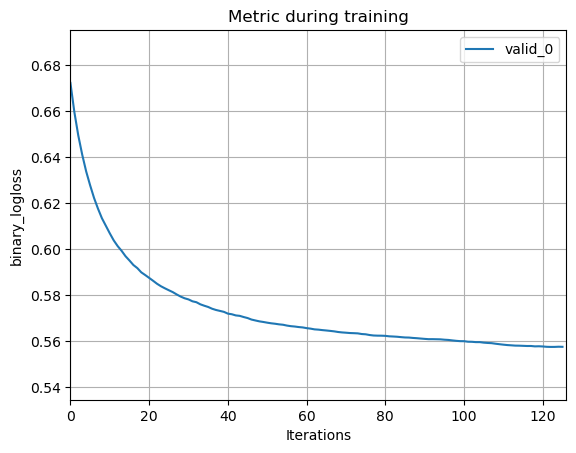

In [200]:
ax = lgb.plot_metric(evals_result, metric="binary_logloss")
plt.show()

In the plot resulting from step 5, you see the values of the binary log loss obtained after each iteration of training the lightGBM. The values reach a plateau at higher iterations, suggesting that the learning converged at a minimum of the optimization function.


#### Evaluating the performance of the model in the three datasets by determining the ROC-AUC and the accuracy of the predictions.


###### Import the sklearn functions to calculate the ROC-AUC and the accuracy:

In [209]:
from sklearn.metrics import roc_auc_score, accuracy_score

`roc_auc_score` → measures how well your model can distinguish between classes (e.g., “disease” vs “no disease”).

* It looks at how the model’s predicted probabilities rank true positives vs false positives.

* Best possible value = 1.0 (perfect classifier).

`accuracy_score` → tells you what fraction of predictions the model got exactly right.

Example: if 90 out of 100 labels are correct, accuracy = 0.9.

💡 `In short`

| Metric       | What it Tells You                 | Typical Range              |
| ------------ | --------------------------------- | -------------------------- |
| **Accuracy** | % of predictions that are correct | 0 → 1                      |
| **ROC AUC**  | How well model separates classes  | 0.5 (random) → 1 (perfect) |


##### Calculate the probability of default in train and test sets:


In [212]:
pred_train = gbm.predict_proba(X_train_enc) [:, 1]
pred_eval = gbm.predict_proba(X_eval_enc) [:, 1]
pred_holdout = gbm.predict_proba(X_holdout_enc) [:, 1]

`gbm.predict_proba(...)`

This gives you predicted probabilities for each class.

Because this is a binary classifier (2 classes: e.g., positive vs negative), the output is a 2D array like:


[[0.2, 0.8],

 [0.9, 0.1],

 
 [0.3, 0.7],

...]

where:

first column → probability of class 0

second column → probability of class 1


[:, 1]  :This means “take the second column only” —
i.e., the probability that each sample belongs to the positive class (1).

So for example:

`pred_eval` = [0.8, 0.1, 0.7, 0.4, ...]

These values are often used to:

Compute AUC (roc_auc_score), or

Create probability thresholds (like saying “label as positive if prob > 0.5”).

`Why you did it for three sets`

| Variable           | Purpose                                                           |
| ------------------ | ----------------------------------------------------------------- |
| **`pred_train`**   | Model’s confidence on training data (helps check for overfitting) |
| **`pred_eval`**    | Model’s confidence on validation data (used for tuning)           |
| **`pred_holdout`** | Model’s confidence on *unseen test data* (final model evaluation) |




##### Calculate the ROC-AUC:



In [232]:
roc_train = roc_auc_score(y_train, pred_train)
roc_eval = roc_auc_score(y_eval, pred_eval)
roc_holdout = roc_auc_score(y_holdout, pred_holdout)

Each line computes the ROC AUC score (Area Under the Receiver Operating Characteristic curve) for one dataset:

| Variable          | Description                                                       |
| ----------------- | ----------------------------------------------------------------- |
| **`roc_train`**   | How well the model separates classes on the **training data**     |
| **`roc_eval`**    | How well it separates classes on the **validation (tuning) data** |
| **`roc_holdout`** | Final performance on **completely unseen test data**              |


`How to interpret the AUC values`

| AUC Score     | Meaning                        |
| ------------- | ------------------------------ |
| **0.5**       | No better than random guessing |
| **0.6 – 0.7** | Weak separation                |
| **0.7 – 0.8** | Fair performance               |
| **0.8 – 0.9** | Good model                     |
| **0.9 – 1.0** | Excellent model                |


##### Print out the  ROC-AUC values

In [238]:
print(f"Train set roc-auc: {roc_train}")
print(f"Eval set roc-auc: {roc_eval}")
print(f"Hold-out set roc-auc: {roc_holdout}")

Train set roc-auc: 0.8200792965564637
Eval set roc-auc: 0.7807894600218679
Hold-out set roc-auc: 0.7721683483318558


`Results`

| Dataset      | ROC-AUC | Interpretation                                                 |
| ------------ | ------- | -------------------------------------------------------------- |
| **Train**    | 0.820   | Model performs quite well on the data it was trained on        |
| **Eval**     | 0.781   | Model performs slightly worse on validation data (as expected) |
| **Hold-out** | 0.772   | Model performs similarly on unseen data — good generalization  |

🧠 `What this means`

AUC ≈ 0.8 → The model can correctly rank a positive sample higher than a negative one about 80% of the time — that’s solid performance!

The small drop from Train (0.82) → Eval (0.78) → Holdout (0.77) shows that:

The model learned meaningful patterns.

It is not severely overfitting — if it were, the training AUC would be much higher (like 0.95+) and test AUC much lower (like 0.60).


`How to read this trend`

| Scenario                           | What it means                               |
| ---------------------------------- | ------------------------------------------- |
| Train AUC ≫ Eval AUC               | Overfitting – model memorized training data |
| Train AUC ≈ Eval AUC ≈ Holdout AUC | Good generalization                         |
| All AUCs low (≈0.5–0.6)            | Model underfitting or poor features         |


##### Predict if the customers will default in train and test sets:

In [243]:
pred_train = gbm.predict(X_train_enc)
pred_eval = gbm.predict(X_eval_enc)
pred_holdout = gbm.predict(X_holdout_enc)

`What happens here`

We are using the .predict() method instead of .predict_proba().

.predict() returns hard class labels — typically 0 or 1.

For example:
[0, 0, 1, 0, 1, 1, 0, ...]

Each value represents whether LightGBM thinks that customer will default (1) or not default (0).


`Difference between .predict() and .predict_proba()`

| Method             | Output                                     | Example                | When to Use                                           |
| ------------------ | ------------------------------------------ | ---------------------- | ----------------------------------------------------- |
| `.predict_proba()` | Probabilities (how confident the model is) | `[0.2, 0.7, 0.9, ...]` | When calculating metrics like **AUC**                 |
| `.predict()`       | Final decision (0 or 1)                    | `[0, 1, 1, ...]`       | When evaluating **accuracy, precision, recall**, etc. |



##### Calculate the accuracy of the predictions:

In [253]:
acc_train = accuracy_score(y_train, pred_train)
acc_eval = accuracy_score(y_eval, pred_eval)
acc_holdout = accuracy_score(y_holdout, pred_holdout)

Each line computes classification accuracy — the proportion of correct predictions — for one of your datasets:

| Variable          | Meaning                                         |
| ----------------- | ----------------------------------------------- |
| **`acc_train`**   | Accuracy of predictions on the **training set** |
| **`acc_eval`**    | Accuracy on the **validation (evaluation) set** |
| **`acc_holdout`** | Accuracy on the **unseen test set (holdout)**   |


##### Print out the accuracy values:

In [258]:
print(f"Train set accuracy: {acc_train}")
print(f"Eval set accuracy: {acc_eval}")
print(f"Hold-out set accuracy: {acc_holdout}")

Train set accuracy: 0.7451542889497027
Eval set accuracy: 0.7145499383477188
Hold-out set accuracy: 0.7080324114849392


`Model Results`
| Dataset      | Accuracy | Interpretation                                              |
| ------------ | -------- | ----------------------------------------------------------- |
| **Train**    | 0.745    | The model correctly predicts ~74.5% of training samples.    |
| **Eval**     | 0.715    | The model correctly predicts ~71.5% of validation samples.  |
| **Hold-out** | 0.708    | The model correctly predicts ~70.8% of unseen test samples. |


`What This Means`

* These are solid results — your model performs consistently across all datasets.

* The drop from 74.5% → 71.5% → 70.8% is small, meaning the model:

Generalizes well 

Isn’t memorizing the training data (not overfitting).

Captures genuine patterns in customer behavior.

`Accuracy Context`

Accuracy of 70–75% is quite respectable for default prediction, since real-world customer default data is:

Noisy (many unpredictable human factors), and

Imbalanced (most customers don’t default).

If your dataset has far more “non-default” cases, then even 71% accuracy may hide stronger AUC performance — which you already saw (~0.77–0.82), confirming good ranking ability.

#### Plot the feature importance

To understand which features are important to predict customer default, a bar plot with the feature importance returned by your model.



Plot feature importance:


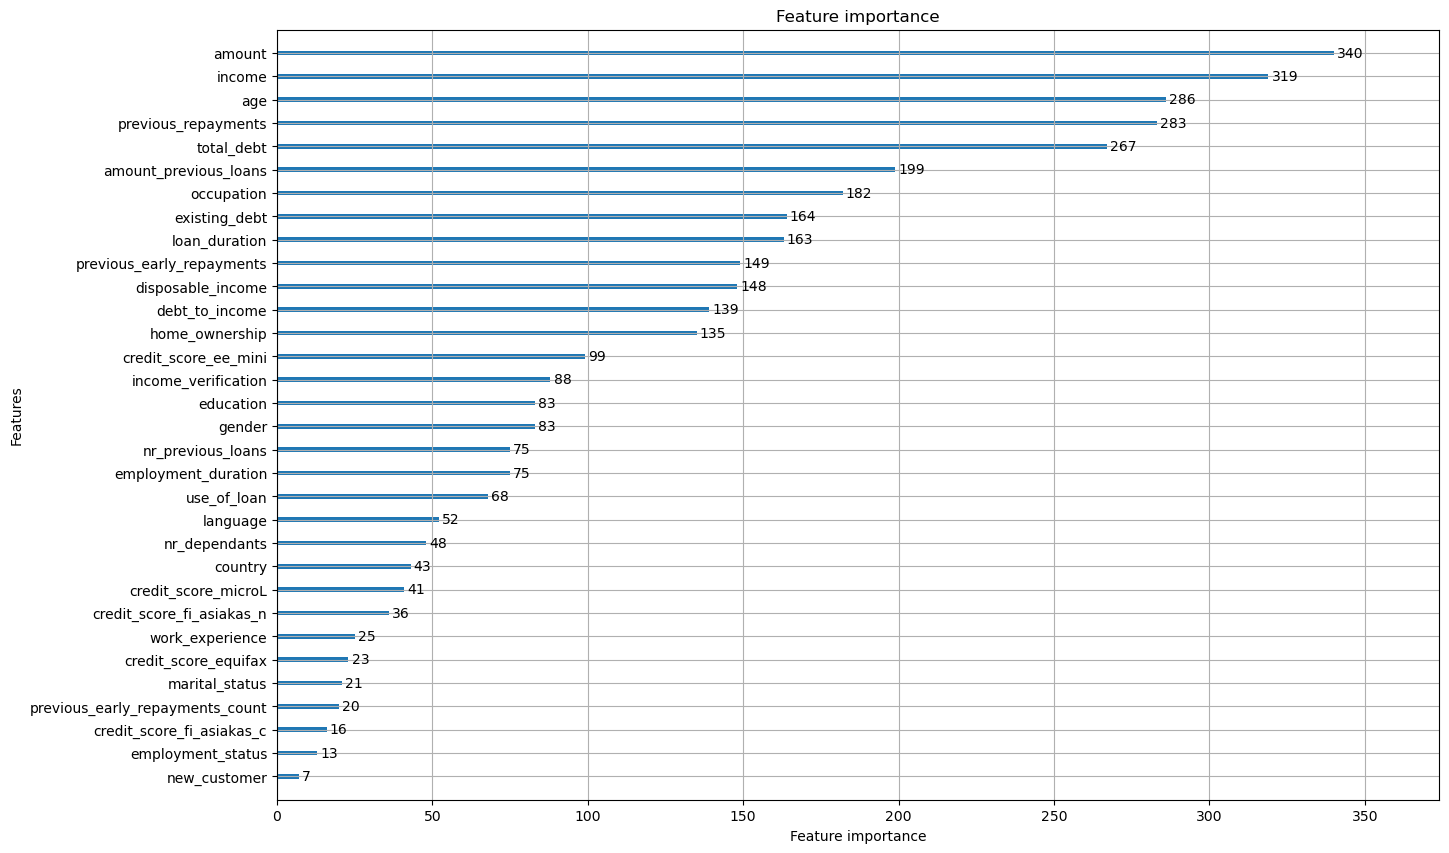

In [268]:
ax = lgb.plot_importance(gbm, figsize=(15, 10))
plt.show()

`What’s happening here`

`lgb.plot_importance(gbm)`

* Creates a bar chart showing which features were most important for LightGBM’s decisions.

* Each bar represents a feature (e.g., credit_score, income, loan_amount, etc.).

* The length of the bar shows how much that feature contributed to improving the model’s accuracy.

`figsize=(15, 10)`

* Makes the figure larger and easier to read (15 inches wide, 10 inches tall).

`plt.show()`

* Displays the chart using Matplotlib.


Unsurprisingly, the amount of money requested by the customer, as well as their income and existing debt, their age, and whether they repaid previous loans, are important indicators of the customer's credit risk.



#### Optimize the parameters of the lightGBM

To squeeze out the maximum possible performance of the lightGBM, optimize its hyperparameters utilizing randomized search.

###### Import the library stats from scipy to define the hyperparameter space and the randomized search from scikit-learn:



In [285]:
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV

##### Set up the lightGBM model:

In [289]:
gbm = lgb.LGBMClassifier(
    num_iterations=1000,
    random_state=10
)

We are creating a LightGBM model (short for Light Gradient Boosting Machine) for a classification task — like predicting whether a customer will default (1) or not (0).

`Parameter breakdown`

| Parameter                 | Meaning                                                                                                                                                                                                 |
| ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`num_iterations=1000`** | The maximum number of **boosting rounds (trees)** LightGBM will build. Each round adds a small decision tree to improve predictions. More trees = potentially better learning, but risk of overfitting. |
| **`random_state=10`**     | Ensures **reproducibility** — if you rerun the code, you’ll get the *exact same results*. Think of it as fixing the "random seed" so your model’s shuffling and sampling behave the same every time.    |


##### Define the hyperparameter space, that is, the range of values for each hyperparameter that should be tested:



In [295]:
param_grid = dict(
    n_estimators=stats.randint(10, 120),
    num_leaves=stats.randint(1, 100),
    max_depth=stats.randint(1, 10),
    learning_rate=stats.uniform(0.0001, 1),
)

`What’s Happening`

We are defining a search space — a set of possible values that RandomizedSearchCV will explore when tuning your LightGBM model.
Each key (like n_estimators) represents a hyperparameter, and each value (stats.randint(...), stats.uniform(...)) defines the range or distribution from which random values will be sampled.

`Breakdown by Parameter`

| Hyperparameter      | Function                               | Range/Distribution                 | Why It Matters                                                                                |
| ------------------- | -------------------------------------- | ---------------------------------- | --------------------------------------------------------------------------------------------- |
| **`n_estimators`**  | Number of boosting iterations (trees)  | Random integers between 10 and 120 | More trees → model learns more, but can overfit; fewer trees → may underfit.                  |
| **`num_leaves`**    | Number of leaves in each tree          | 1 to 100                           | Controls model complexity. More leaves = more splits = higher capacity to learn patterns.     |
| **`max_depth`**     | Maximum depth per tree                 | 1 to 10                            | Limits how deep each tree can grow. Helps prevent overfitting by controlling tree complexity. |
| **`learning_rate`** | Shrinks how much each tree contributes | Random floats between 0.0001 and 1 | Smaller = slower, more stable learning; larger = faster learning but risk of overshooting.    |


`Why We Call This “Hyperparameter Space”`

Imagine each hyperparameter is a dimension in a big 3D/4D space.

Every possible combination (like n_estimators=80, max_depth=6, learning_rate=0.15, etc.) is a point in that space.

The optimization algorithm (like RandomizedSearchCV) samples points randomly from this space to find the best performing one.

So this param_grid is essentially the map that tells your model tuner where it’s allowed to explore.

`Summary`

| Concept                  | Explanation                                                                                  |
| ------------------------ | -------------------------------------------------------------------------------------------- |
| **Hyperparameter space** | The range of possible values the model tuner will test.                                      |
| **Why define it?**       | To give the search algorithm boundaries for experimentation.                                 |
| **Goal**                 | Find the best mix of parameters that maximizes model performance while avoiding overfitting. |


`NOTE:` you could test more hyperparameters than the ones shown here.

##### Set up the randomized search to optimize the ROC-AUC using 3-fold cross-validation:


In [306]:
search = RandomizedSearchCV(
    gbm,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_iter=150,
    random_state=10,
    refit=True,
)

`What This Code Does`

You’re telling scikit-learn to run a randomized hyperparameter search using your defined search space (param_grid) and to pick the combination that produces the highest ROC-AUC score.

`Breakdown by Parameter`

| Parameter               | Meaning                                                                            | Why It’s Used                                                                                                                  |
| ----------------------- | ---------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **`gbm`**               | Your base model (`LGBMClassifier`)                                                 | This is the model being tuned.                                                                                                 |
| **`param_grid`**        | The hyperparameter space (ranges from `stats.randint`, `stats.uniform`, etc.)      | Tells the search where to look for good parameter values.                                                                      |
| **`scoring='roc_auc'`** | Uses the **Area Under the ROC Curve** as the performance metric                    | AUC is more informative than accuracy for imbalanced problems like credit defaults.                                            |
| **`cv=3`**              | 3-fold cross-validation                                                            | Splits the training data into 3 parts — trains on 2, validates on 1, then rotates. Gives a more reliable performance estimate. |
| **`n_iter=150`**        | Number of random combinations to test                                              | The higher this number, the more chances you have of finding an optimal configuration.                                         |
| **`random_state=10`**   | Ensures reproducibility                                                            | Makes sure your random trials are consistent each time you run the code.                                                       |
| **`refit=True`**        | After finding the best parameters, retrains the model using the full training data | Gives you a final model ready for evaluation or deployment.                                                                    |

`What’s Happening Behind the Scenes`

RandomizedSearchCV samples 150 random combinations of hyperparameters from your param_grid.

For each combination:

It trains your LightGBM model.

Evaluates it using 3-fold cross-validation.

Computes the average ROC-AUC across folds.

After all iterations, it picks the combination with the highest AUC score and retrains the model on all training data.

##### Carry out the randomized search (this step will take several minutes to run):


In [310]:
search.fit(
    X=X_train_enc,
    y=y_train,
    eval_set=[(X_eval_enc, y_eval)],
    categorical_feature=cols_cat,
    callbacks=[lgb.early_stopping(3)],
)

[LightGBM] [Info] Number of positive: 19735, number of negative: 15588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2217
[LightGBM] [Info] Number of data points in the train set: 35323, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.558701 -> initscore=0.235892
[LightGBM] [Info] Start training from score 0.235892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 3 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

C:\Users\momondi\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\momondi\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\momondi\AppData\Local\anaconda3\Lib\site-packages\lightgbm\sklearn.py", line 1560, in fit
    super().fit(
  File "C:\Users\momondi\AppData\Local\anaconda3\Lib\site-packages\lightgbm\sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^

[LightGBM] [Info] Number of positive: 29603, number of negative: 23382
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2223
[LightGBM] [Info] Number of data points in the train set: 52985, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.558705 -> initscore=0.235909
[LightGBM] [Info] Start training from score 0.235909
Training until validation scores don't improve for 3 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

RandomizedSearchCV(cv=3,
                   estimator=LGBMClassifier(num_iterations=1000,
                                            random_state=10),
                   n_iter=150,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000119ACE35280>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000119ACB72930>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000119ACB9EB10>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000119ACB963F0>},
                   random_state=10, scoring='roc_auc')

`Step-by-Step Breakdown`

| Part                                    | What It Does                                                                                                   | Why It Matters                                                                                    |
| --------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| **`search.fit(...)`**                   | Runs the **RandomizedSearchCV** optimization you set up earlier, testing many combinations of hyperparameters. | This is where the actual tuning and training happens.                                             |
| **`X_train_enc, y_train`**              | Your training features and labels (already encoded).                                                           | These are used to train and evaluate multiple candidate models.                                   |
| **`eval_set=[(X_eval_enc, y_eval)]`**   | Provides a **validation dataset** for LightGBM to monitor performance at each boosting iteration.              | Allows the model to stop early when validation performance stops improving (reduces overfitting). |
| **`categorical_feature=cols_cat`**      | Tells LightGBM which columns are **categorical** (e.g., gender, region, etc.).                                 | LightGBM can handle categorical splits natively, so you don’t need to one-hot encode.             |
| **`callbacks=[lgb.early_stopping(3)]`** | Stops training if the validation metric hasn’t improved in **3 consecutive rounds**.                           | Saves time and prevents overfitting — very useful when you’re testing hundreds of parameter sets. |


`How It All Works Together`

During the randomized search:

LightGBM trains a model using one random combination of hyperparameters.

It evaluates each boosting round on the validation set.

If there’s no improvement for 3 rounds, it stops early.

RandomizedSearchCV records the best ROC-AUC for that trial.

Steps 1–4 repeat for up to 150 combinations (from your previous setup).

At the end, `search.best_params_` will show the combination that gave the highest AUC.

##### Display the best hyperparameters:


In [312]:
search.best_params_

{'learning_rate': 0.06819727353795003,
 'max_depth': 8,
 'n_estimators': 18,
 'num_leaves': 86}

`What Each Parameter Means (and Why It Matters)`

| Parameter                   | Meaning                                               | Interpretation                                                                                                                                               |
| --------------------------- | ----------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`learning_rate = 0.068`** | Controls how quickly the model learns from new trees. | This is a **moderately low learning rate** — ideal for stability and preventing overfitting. Each tree adds small, precise corrections.                      |
| **`max_depth = 8`**         | Maximum depth of each decision tree.                  | Deeper trees (like 8) let the model capture complex relationships, but not too deep to overfit — a nice balance.                                             |
| **`n_estimators = 18`**     | Number of boosting rounds (trees) to build.           | Only **18 trees** were needed! Early stopping likely stopped the model before hitting your limit of 1000 iterations — meaning the model converged quickly. ⚡ |
| **`num_leaves = 86`**       | Maximum number of leaves in a single tree.            | Each leaf is a possible final decision. 86 leaves = moderately complex trees → enough power to capture patterns but not excessive complexity.                |


`In Plain English`

The model learns slowly but precisely (learning_rate ~0.07), with medium-deep trees (depth=8) that have 86 leaf nodes, and needed only 18 boosting rounds to reach its best validation AUC.

This is a stable, efficient, and well-regularized configuration — great signs of generalization

##### These are the best hyperparameters found by the randomized search for the lightGBM given your training data set:


In [314]:
{'learning_rate': 0.17673504593674882,
 'max_depth': 7,
 'n_estimators': 117,
 'num_leaves': 95}

{'learning_rate': 0.17673504593674882,
 'max_depth': 7,
 'n_estimators': 117,
 'num_leaves': 95}

1️⃣ `learning_rate = 0.1767`

This controls how fast the model learns from each tree.

A value around 0.17 is moderately high, meaning:

The model learns fairly quickly.

It converges faster but could slightly risk overfitting if not paired with proper regularization (which your search handled).

✅ Interpretation: The model found that learning faster was effective — probably because your dataset has clear patterns the model can capture efficiently.

🔍 2️⃣ `max_depth = 7`

This is the maximum depth of each tree.

Trees up to 7 levels deep can capture complex feature interactions (like non-linear relationships) but still generalize well.

✅ Interpretation: The model is moderately complex — deep enough to capture meaningful patterns without memorizing the data.

🔍 3️⃣ `n_estimators = 117`

Number of boosting iterations (trees).

So your model builds 117 trees sequentially — each one correcting the errors of the previous.

✅ Interpretation: The model needed a decent number of trees to balance bias and variance — not too few (underfitting), not too many (overfitting).

🔍 4️⃣ `num_leaves = 95`

The maximum number of leaves in each tree.

Leaves represent final decision points in the tree — more leaves = more detailed splits.

✅ Interpretation: 95 leaves mean your trees are fairly rich in structure, capable of capturing complex decision boundaries.

5️⃣ `How this combination works together`

| Hyperparameter           | What It Controls          | Behavior of Your Model               |
| ------------------------ | ------------------------- | ------------------------------------ |
| `learning_rate = 0.1767` | Step size of learning     | Learns quickly and confidently       |
| `max_depth = 7`          | Tree complexity           | Moderately deep, balanced trees      |
| `n_estimators = 117`     | Number of boosting rounds | Enough iterations to converge        |
| `num_leaves = 95`        | Tree flexibility          | Can represent detailed relationships |


Together, this combination suggests a fast-learning, moderately deep model that generalizes well and captures meaningful structure in your data.

#### Plot the results of the hyperparameter search

To try and understand if you found the best hyperparameters or if there is room for improvement, we are ploting the ROC-AUC values obtained for each hyperparameter combination evaluated during the search.


Capture the results of the search in a pandas dataframe:

`results = pd.DataFrame(search.cv_results_)`

Tip: explore the dataframe resulting from step 1 to familiarize yourself with the content.

This converts the full record of every parameter combination and its performance (mean AUC, std AUC, etc.) into a pandas DataFrame, making it easy to inspect and plot.

results.head()

`You’ll see columns like:`

* param_learning_rate

* param_max_depth

* param_n_estimators

* mean_test_score (this is your ROC-AUC metric)

* rank_test_score (ranking of each combination)

💡 mean_test_score is what RandomizedSearchCV optimized — the average ROC-AUC across folds.


In [360]:
results = pd.DataFrame(search.cv_results_)

Sort the dataframe according to the ROC-AUC values in ascending order:

`results.sort_values(by='mean_test_score', ascending=True, inplace=True)`

Sorting helps you see how performance varies from worst → best.

If you want the top-performing hyperparameters:

`results.tail(5)`  # Show the 5 best combinations


In [362]:
results.tail(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_num_leaves,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
145,0.800424,0.268537,0.118470,0.031110,0.051956,8,12,24,"{'learning_rate': 0.051956261830692366, 'max_d...",0.763579,0.768269,0.766795,0.766214,0.001958,11
146,1.146574,0.212924,0.143613,0.017735,0.104964,2,66,37,"{'learning_rate': 0.10496441826109394, 'max_de...",0.752763,0.752582,0.755992,0.753779,0.001566,58
147,0.994093,0.115741,0.088772,0.006466,0.162902,4,69,87,"{'learning_rate': 0.16290211716212033, 'max_de...",0.758534,0.769090,0.767413,0.765012,0.004632,15
148,0.351360,0.071611,0.038178,0.002889,0.803435,8,14,88,"{'learning_rate': 0.8034347795330135, 'max_dep...",0.731412,0.740853,0.742821,0.738362,0.004980,123
149,1.009909,0.421202,0.094935,0.015407,0.243975,3,69,36,"{'learning_rate': 0.24397509597581102, 'max_de...",0.756298,0.762141,0.761708,0.760049,0.002659,35


In [364]:
results.sort_values(by='mean_test_score', ascending=True, inplace=True)

In [366]:
results = pd.DataFrame(search.cv_results_)

Reset the index:

`results.reset_index(drop=True, inplace=True)`

This ensures the DataFrame has a clean, sequential index after sorting — useful for plotting.



In [368]:
results.reset_index(drop=True, inplace=True)

##### Plot the ROC-AUC value returned by each hyperparameter combination:

Text(0.5, 0, 'Hyperparameter combinations')

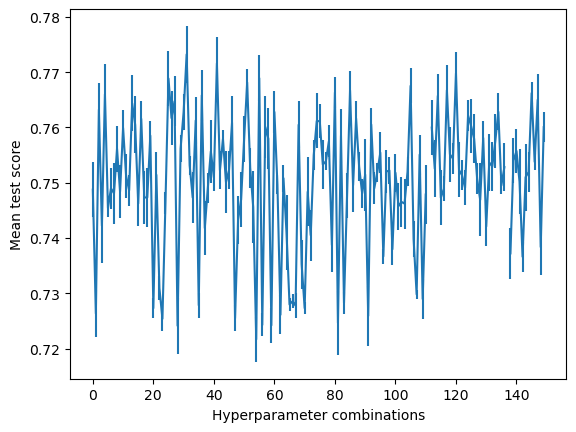

In [370]:
results['mean_test_score'].plot(
        yerr=[results['std_test_score'],
                        results['std_test_score']],
        subplots=True)


plt.ylabel('Mean test score')
plt.xlabel('Hyperparameter combinations')
